In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from MLP import MLP,train,test
from Gradcheck import GradientsChecker,check_grads,WarmupCosineSchedular
from Optimizer import Adam,RMSProp,SGD,AdamW
from sklearn.model_selection import train_test_split

In [2]:
data=pd.read_csv('clean.csv')

In [3]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,1.0
1,1,1,1,38.0,1,0,71.2833,2.0
2,1,3,1,26.0,0,0,7.9250,1.0
3,1,1,1,35.0,1,0,53.1000,1.0
4,0,3,0,35.0,0,0,8.0500,1.0


In [4]:
x=data.drop('Survived',axis=1)
y=data['Survived']

In [5]:
y=y.to_numpy().reshape(-1,1)

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
model=MLP(7,10,1)
optim=Adam(model)

In [ ]:
print("======LAUNCHING GRADEINTS CHECCKING========")
train_losses=[]
diff=GradientsChecker.check(model,x_train,y_train)
print(f"Relative Difference is :{diff}")
if diff<1e-7:
    print("succes :Every thing is correct")
elif diff<1e-4:
    print("Wrong :Minor precision")
else:
    print("Fianal Error : Check your implementation line by line")
epochs=int(input("How many epochs you want to train your model :"))
for epoch in range(epochs):
    y_pred=model.forward(x_train)
    loss=model.compute_loss(y_pred,y_train)
    train_losses.append(loss)
    model.backward(y_train)
    optim.step()

    if epoch %100==0:
        print(f"epoch :{epoch}   | Loss :{loss}")

In [ ]:
test_losses=[]
for epoch in range(len(x_test)):
    pred=model.forward(x_test)
    test_loss=model.compute_loss(pred,y_test)
    test_losses.append(test_loss)
    prediction=np.mean(pred>=0.5).astype(int)
    acc=np.mean(prediction==y_test)

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses,label="Adam Training Loss")
plt.plot(test_losses,label="Adam test loss",c='r')
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.title("Loss curve ")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
model2=MLP(7,10,1)
optimizer=AdamW(model2)

In [ ]:
print("======LAUNCHING GRADEINTS CHECCKING========")
train_losses2=[]
diff2=GradientsChecker.check(model2,x_train,y_train)
print(f"Relative Difference is :{diff2}")
if diff<1e-7:
    print("succes :Every thing is correct")
elif diff<1e-4:
    print("Wrong :Minor precision")
else:
    print("Fianal Error : Check your implementation line by line")
epochs=int(input("How many epochs you want to train your model :"))
for epoch in range(epochs):
    y_pred=model2.forward(x_train)
    loss2=model2.compute_loss(y_pred,y_train)
    train_losses2.append(loss2)
    model2.backward(y_train)
    optimizer.step()

    if epoch %100==0:
        print(f"epoch :{epoch}   | Loss :{loss}")

In [ ]:
test_losses2=[]
for epoch in range(len(x_test)):
    pred2=model2.forward(x_test)
    test_loss2=model2.compute_loss(pred2,y_test)
    test_losses2.append(test_loss2)
    prediction2=np.mean(pred>=0.5).astype(int)
    acc2=np.mean(prediction2==y_test)

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses2,label="AdamW Training Loss")
plt.plot(test_losses2,label="AdamW test loss",c='r')
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.title("Loss curve ")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
model3=MLP(7,10,1)
optim2=AdamW(model3,)

In [9]:
total_epochs=10
batch_per_epoch=1000
total_steps=total_epochs*batch_per_epoch
WARMUP_STEPS=1000

schedular=WarmupCosineSchedular(peak_lr=1e-3,
                                warmup_steps=WARMUP_STEPS,
                                total_steps=total_steps,
                                min_lr=1e-5)


In [10]:
losses=train(model3,x_train,y_train,epochs=2000,optimizer=optim2)

Epoch 0  | Loss :  0.9434313525339966
Epoch 100  | Loss :  0.7369688281381607
Epoch 200  | Loss :  0.6263407883420199
Epoch 300  | Loss :  0.6034063668540985
Epoch 400  | Loss :  0.5940628671207543
Epoch 500  | Loss :  0.584671806047738
Epoch 600  | Loss :  0.5585541699050669
Epoch 700  | Loss :  0.5393763278105647
Epoch 800  | Loss :  0.5278661550225534
Epoch 900  | Loss :  0.5184412088102718
Epoch 1000  | Loss :  0.506310288582925
Epoch 1100  | Loss :  0.4764288914588536
Epoch 1200  | Loss :  0.4603916235088238
Epoch 1300  | Loss :  0.4505771095725155
Epoch 1400  | Loss :  0.4439513535800509
Epoch 1500  | Loss :  0.43941894245950536
Epoch 1600  | Loss :  0.4358147606777891
Epoch 1700  | Loss :  0.43268538753554137
Epoch 1800  | Loss :  0.4298699985035058
Epoch 1900  | Loss :  0.42726502165991687


In [11]:
preds,test_loses=test(model3,x_test,y_test)

Test Loss is :0.4653983817999609


In [13]:
test_loses

[0.4653983817999609]

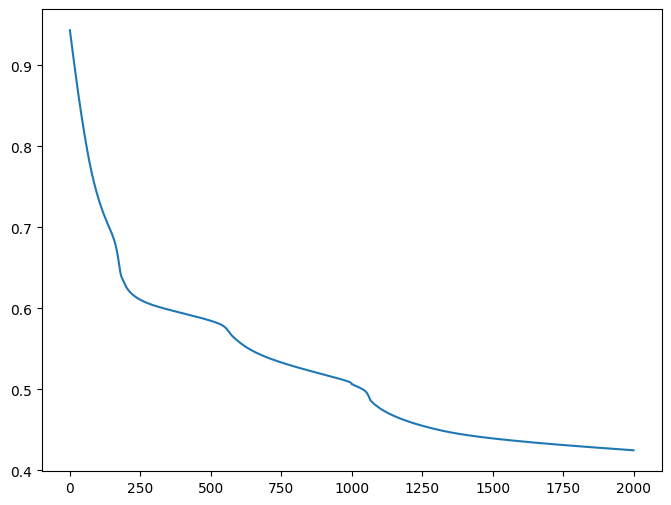

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(losses,label="train")
plt.plot(test_loses)